# Lab: Recognising low-resolution handwritten digits with a Vision Transformer

This notebook has been prepared by Hsiu-Wen Chang from MINES ParisTech
Shall you have any problem, send me [email](hsiu-wen.chang_joly@mines-paristech.fr)

In this notebook, we classify handwritten digits from **16 × 16 grayscale images** using a compact Vision Transformer (ViT). Unlike a convolutional neural network, a ViT sees an image as a sequence of patches and learns how patches relate through self-attention.

## Learning objectives

You will learn to:

- inspect a small image-classification dataset;
- split an image into patches and turn them into token embeddings;
- use a class token, positional embeddings, and Transformer encoder blocks;
- train and evaluate a Vision Transformer;
- visualise correct and incorrect digit predictions.

## Vision Transformer summary

![ViT](figures/ViT.png)

ViT model consists of three main components:

 - Embedding Layer: The image is first divided into fixed-size patches (e.g., 4×4 pixels), which are then flattened and linearly projected into high-dimensional vectors. A special [CLS] token is also prepended to the sequence, similar to NLP Transformers. This is conceptually similar to how text is tokenized and embedded in LLMs except that the “tokens” here are image patches instead of words or subwords.
 - Transformer Encoder: These patch embeddings are then fed into a standard Transformer encoder. Through multiple layers of multi-head self-attention and feed-forward networks, each patch learns to attend to other patches, capturing global context and spatial relationships across the image.
 - Classification Head (MLP Head): Finally, the output corresponding to the [CLS] token is passed through a multilayer perceptron (MLP) head. This consists of one or more linear layers that transform the representation into a vector of size 10, corresponding to the number of possible image classes.

## 1. Imports and reproducibility

We use the `digits` dataset bundled with scikit-learn, so no data download is required. Its images are intentionally low-resolution: each image has only 64 pixels. The lesson requires `torch`, `scikit-learn`, and `matplotlib`; if they are missing, run `%pip install torch scikit-learn matplotlib` in a notebook cell first.

In [8]:
import torch
import random
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using:', device)

transform = transforms.ToTensor()

all_dataset = datasets.SEMEION(
    root="./data",
    download=True,
    transform=transform
)

images = torch.stack([sample[0] for sample in all_dataset])
labels = torch.tensor([sample[1] for sample in all_dataset])

print("Image shape (num_samples, channels, height, width):", images.shape)
print("Labels values: {} and shape: {}:".format(torch.unique(labels), labels.shape))

Using: cuda
Image shape (num_samples, channels, height, width): torch.Size([1593, 1, 16, 16])
Labels values: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]) and shape: torch.Size([1593]):


## 2. Explore the handwritten-digit data

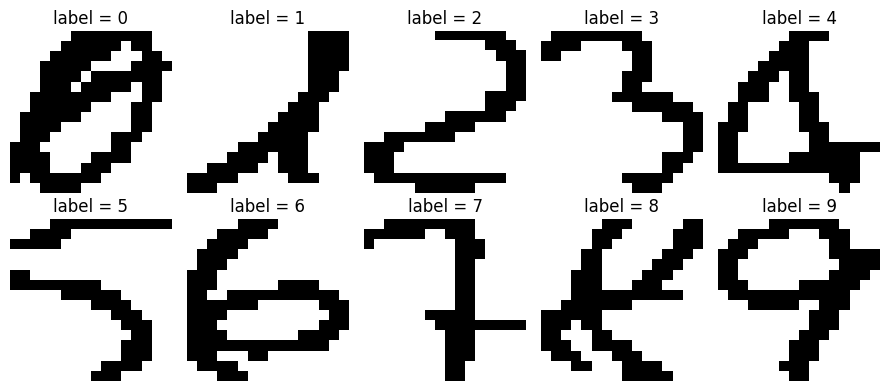

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
for digit, ax in enumerate(axes.flat):
    index = np.where(labels == digit)[0][0]
    ax.imshow(images[index][0], cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(f'label = {digit}')
    ax.axis('off')
plt.tight_layout()

## 3. Train/test split and data loaders

A stratified split preserves the proportion of each digit in both partitions. PyTorch expects a channel dimension, so images have shape `(N, 1, 8, 8)`.

In [3]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.8 * len(all_dataset))
test_size = len(all_dataset) - train_size

train_set, test_set = random_split(
    all_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_set,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_set,
    batch_size=64,
    shuffle=False
)
    
print(f'Training examples: {len(train_set)} | test examples: {len(test_set)}')

Training examples: 1274 | test examples: 319


## 4. From image patches to a sequence

We divide every 16 × 16 image into non-overlapping 4 × 4 patches using `tensor.unfold(dimension, size, step)` function. This function is essentially the sliding-window operation underlying convolution. This produces a sequence of 16 patch tokens. 

In [4]:
PATCH_SIZE = 4

def image_to_patches(x, patch_size=PATCH_SIZE):
    """Convert (batch, channels, height, width) images to (batch, patches, pixels)."""
    batch, channels, height, width = x.shape
    assert height % patch_size == 0 and width % patch_size == 0
    x = x.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    # (batch, channel, patches_y, patches_x, patch_y, patch_x)
    return x.permute(0, 2, 3, 1, 4, 5).reshape(batch, -1, channels * patch_size ** 2)

one_batch, _ = next(iter(train_loader))
patches = image_to_patches(one_batch[:1])
print('One image:', tuple(one_batch[:1].shape))
print('Patch sequence:', tuple(patches.shape), '(16 patches, 16 pixels per patch)')

One image: (1, 1, 16, 16)
Patch sequence: (1, 16, 16) (16 patches, 16 pixels per patch)


## 5. A compact Vision Transformer
`nn.TransformerEncoder` stacks multi-head self-attention and feed-forward layers. 

`batch_first=True` makes the token sequence shape `(batch, sequence, embedding)`. Dropout is included to reduce overfitting.

*** class_token [CLS] does not contain any image information at the start but is designed to aggregate information from all patches during the attention process. After passing through the Transformer encoder, the [CLS] token’s final state is used by the classification head to predict the image class.

In [5]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size=16, patch_size=4, channels=1,
                 embedding_dim=64, heads=4, depth=3, classes=10):
        super().__init__()
        assert image_size % patch_size == 0
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        patch_dim = channels * patch_size ** 2
        self.patch_embedding = nn.Linear(patch_dim, embedding_dim)
        # add a class token (CLS, a summery of the image) and a position embedding to the patch embeddings
        self.class_token = nn.Parameter(torch.zeros(1, 1, embedding_dim))
        self.position_embedding = nn.Parameter(torch.zeros(1, self.num_patches + 1, embedding_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim, nhead=heads, dim_feedforward=embedding_dim * 2,
            dropout=0.1, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.classifier = nn.Sequential(nn.LayerNorm(embedding_dim), nn.Linear(embedding_dim, classes))
        nn.init.trunc_normal_(self.position_embedding, std=0.02)
        nn.init.trunc_normal_(self.class_token, std=0.02)

    def forward(self, x):
        tokens = self.patch_embedding(image_to_patches(x, self.patch_size))
        class_token = self.class_token.expand(x.size(0), -1, -1)
        tokens = torch.cat([class_token, tokens], dim=1)
        tokens = tokens + self.position_embedding
        encoded = self.transformer(tokens)
        return self.classifier(encoded[:, 0])

    def get_attention_maps(self, x):
        tokens = self.patch_embedding(image_to_patches(x, self.patch_size))
        class_token = self.class_token.expand(x.size(0), -1, -1)
        tokens = torch.cat([class_token, tokens], dim=1)
        tokens = tokens + self.position_embedding
        attention_maps = []
        for layer in self.transformer.layers:
            # Get the attention weights from the multi-head attention layer
            attn_output, attn_weights = layer.self_attn(tokens, tokens, tokens, need_weights=True)
            attention_maps.append(attn_weights)
            tokens = layer.norm1(tokens + layer.dropout1(attn_output))
            feedforward_output = layer.linear2(layer.dropout(layer.activation(layer.linear1(tokens))))
            tokens = layer.norm2(tokens + layer.dropout2(feedforward_output))
        return attention_maps


model = VisionTransformer().to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

VisionTransformer(
  (patch_embedding): Linear(in_features=16, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=64, out_features=10, bias=True)
  )
)
Parameters: 103,434


/home/kelly/miniconda/envs/nerf_env/lib/python3.14/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 6. Train the model

Cross-entropy compares the 10 output logits against the correct digit. The dataset is small, so 25 epochs should finish quickly on CPU.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

def accuracy(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            predicted = logits.argmax(dim=1).cpu()
            correct += (predicted == y).sum().item()
            total += len(y)
    return correct / total

history = {'loss': [], 'train_accuracy': [], 'test_accuracy': []}
for epoch in range(1, 26):
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    history['loss'].append(total_loss / len(train_loader.dataset))
    history['train_accuracy'].append(accuracy(train_loader))
    history['test_accuracy'].append(accuracy(test_loader))
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d} | loss {history['loss'][-1]:.3f} | test accuracy {history['test_accuracy'][-1]:.1%}")

Epoch  5 | loss 0.749 | test accuracy 72.1%
Epoch 10 | loss 0.318 | test accuracy 90.3%
Epoch 15 | loss 0.172 | test accuracy 90.6%
Epoch 20 | loss 0.141 | test accuracy 89.7%
Epoch 25 | loss 0.125 | test accuracy 94.0%


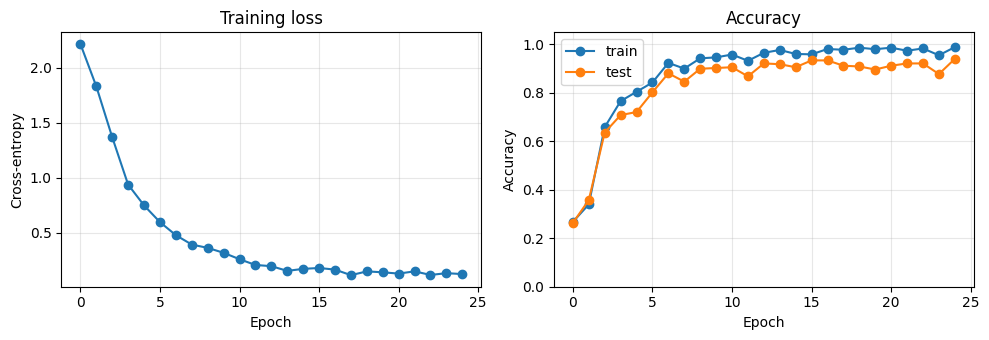

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history['loss'], marker='o')
axes[0].set(title='Training loss', xlabel='Epoch', ylabel='Cross-entropy')
axes[0].grid(alpha=0.3)
axes[1].plot(history['train_accuracy'], label='train', marker='o')
axes[1].plot(history['test_accuracy'], label='test', marker='o')
axes[1].set(title='Accuracy', xlabel='Epoch', ylabel='Accuracy', ylim=(0, 1.05))
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()

**Question** Train and test the performances of different size of patches (2x2, 4x4, 8x8) and different depth of the transformer (1, 2, 3). Report the results in a table.

## 7. Inspect predictions

A high aggregate score can hide systematic errors. Plotting examples lets us see which writing styles or digit pairs challenge the model.

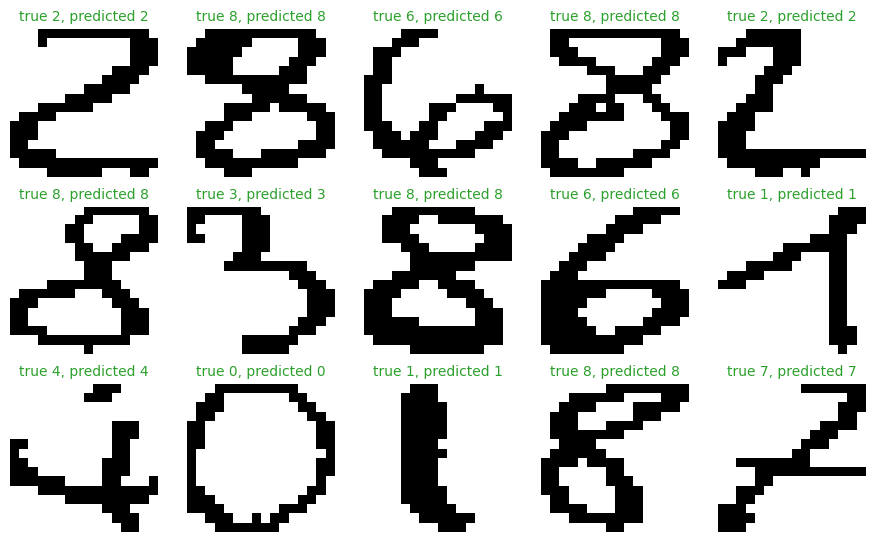

In [8]:
X_test, y_test = zip(*test_set)
X_test = torch.stack(X_test).numpy()
model.eval()
with torch.no_grad():
    test_logits = model(torch.from_numpy(X_test).to(device))
    #attention_weights[layer][batch, head, query, key], we will use it later to visualize the attention maps for a specific layer and head
    attention_weights = model.get_attention_maps(torch.from_numpy(X_test).to(device))

    test_predictions = test_logits.argmax(dim=1).cpu().numpy()


fig, axes = plt.subplots(3, 5, figsize=(9, 5.5))
for i, ax in enumerate(axes.flat):
    index = i * 7  # spread samples across the test set
    truth, predicted = y_test[index], test_predictions[index]
    color = 'tab:green' if truth == predicted else 'tab:red'
    ax.imshow(X_test[index, 0], cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(f'true {truth}, predicted {predicted}', color=color, fontsize=10)
    ax.axis('off')
plt.tight_layout()

Mistakes: 19 / 319


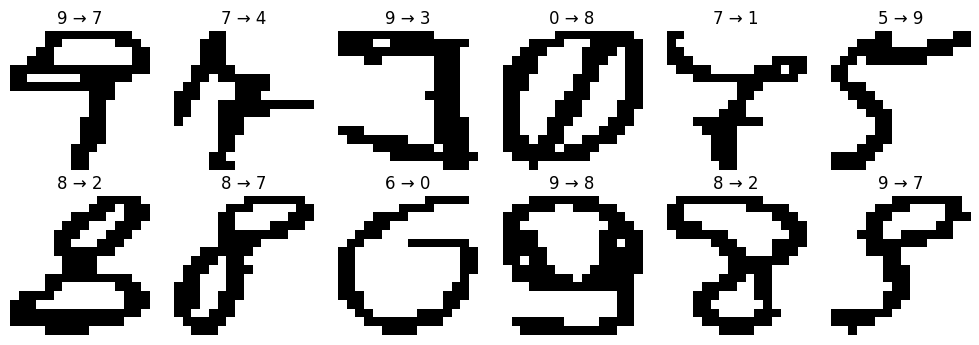

In [9]:
mistakes = np.where(test_predictions != y_test)[0]
print(f'Mistakes: {len(mistakes)} / {len(y_test)}')
if len(mistakes):
    fig, axes = plt.subplots(2, min(6, len(mistakes)), figsize=(10, 3.5))
    for ax, index in zip(axes.flat, mistakes):
        ax.imshow(X_test[index,0], cmap='gray_r', vmin=0, vmax=1)
        ax.set_title(f'{y_test[index]} → {test_predictions[index]}')
        ax.axis('off')
    for ax in axes.flat[len(mistakes):]:
        ax.axis('off')
    plt.tight_layout()

## 8. Attention over original images

Text(0.5, 1.0, 'Attention Map (Last Layer, Head 0) \n 5 → 5')

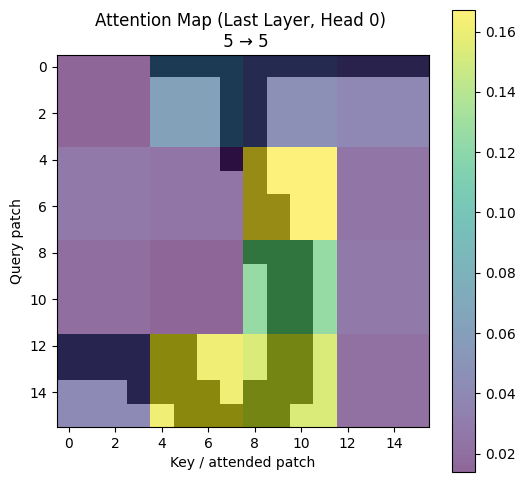

In [10]:
#Choose any image you like
index = 100

plt.figure(figsize=(6, 6))
plt.imshow(X_test[index,0], cmap='gray_r', vmin=0, vmax=1)
# Use the selected image's CLS-to-patch attention from the last layer
selected_attention = attention_weights[-1][index, 0, 1:].detach().cpu()
selected_map = selected_attention.reshape(PATCH_SIZE, PATCH_SIZE)
selected_image = selected_map.repeat_interleave(
    PATCH_SIZE, dim=0
).repeat_interleave(PATCH_SIZE, dim=1)

plt.imshow(selected_image.numpy(), cmap='viridis', alpha=0.6)
plt.xlabel("Key / attended patch")
plt.ylabel("Query patch")
plt.colorbar()
plt.title(f'Attention Map (Last Layer, Head 0) \n {y_test[index]} → {test_predictions[index]}')


**Question** Use this function to investigate the image with wrong prediction and explain the reason.

### Conclusion

Vision Transformers represent an image as an ordered sequence of patch tokens. Self-attention lets each patch exchange information with every other patch, while positional embeddings preserve spatial order. On very small datasets and images, this compact implementation is mainly a learning tool; production-scale ViTs usually need far more data, augmentation, or pretraining.

**Extension Question** Reuse the code in RNN practical lesson and train a transformer to solve the English-French translation task. You should be able to see that which English words are important to the target french word. 

In [13]:
import random
import re
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path


DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip'
data_dir = Path('data')
archive_path = data_dir / 'fra-eng.zip'
text_path = data_dir / 'fra-eng' / 'fra.txt'
data_dir.mkdir(exist_ok=True)

if not text_path.exists():
    if not archive_path.exists():
        print('Downloading English–French corpus...')
        urllib.request.urlretrieve(DATA_URL, archive_path)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(data_dir)

def preprocess(text):
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    return re.sub(r'([,.!?])', r' \1 ', text)

def load_pairs(path, max_pairs=800, max_tokens=8):
    result = []
    for line in path.read_text(encoding='utf-8').splitlines():
        fields = line.split('\t')
        if len(fields) < 2:
            continue
        english, french = (preprocess(fields[0]), preprocess(fields[1]))
        if 0 < len(english.split()) <= max_tokens and 0 < len(french.split()) <= max_tokens:
            result.append((english, french))
        if len(result) == max_pairs:
            break
    return result

pairs = load_pairs(text_path)
random.shuffle(pairs)
split = int(0.85 * len(pairs))
train_pairs, test_pairs = pairs[:split], pairs[split:]
print(f'{len(train_pairs)} training pairs, {len(test_pairs)} test pairs')
train_pairs[:4]

PAD, SOS, EOS, UNK = '<pad>', '<sos>', '<eos>', '<unk>'

def tokenize(text):
    return text.split()

def build_vocab(sentences):
    counts = Counter(token for sentence in sentences for token in tokenize(sentence))
    tokens = [PAD, SOS, EOS, UNK] + sorted(counts)
    stoi = {token: i for i, token in enumerate(tokens)}
    return stoi, tokens

src_stoi, src_tokens = build_vocab([en for en, _ in train_pairs])
tgt_stoi, tgt_tokens = build_vocab([fr for _, fr in train_pairs])

SRC_PAD = src_stoi[PAD]
TGT_PAD = tgt_stoi[PAD]
SRC_BOS = src_stoi[SOS]
SRC_EOS = src_stoi[EOS]
TGT_BOS = tgt_stoi[SOS]
TGT_EOS = tgt_stoi[EOS]

def numericalize(text, stoi, add_sos=False, add_eos=True):
    ids = [stoi.get(token, stoi[UNK]) for token in tokenize(text)]
    if add_sos:
        ids = [stoi[SOS]] + ids
    if add_eos:
        ids = ids + [stoi[EOS]]
    return torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(1)  # (length, batch=1)

680 training pairs, 120 test pairs


### Modify previous code to use `Dataset` and `DataLoader` 

In [14]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_stoi, tgt_stoi):
        self.pairs = pairs
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi

    def encode(self, tokens, vocab):
        unk = vocab[UNK]
        return [vocab[SOS]] + [vocab.get(t, unk) for t in tokens] + [vocab[EOS]]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_tokens, tgt_tokens = self.pairs[idx]
        src = torch.tensor(self.encode(src_tokens, self.src_stoi), dtype=torch.long)
        tgt = torch.tensor(self.encode(tgt_tokens, self.tgt_stoi), dtype=torch.long)
        return src, tgt


def collate_fn(batch):
    src, tgt = zip(*batch)

    src = nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=SRC_PAD)
    tgt = nn.utils.rnn.pad_sequence(tgt, batch_first=True, padding_value=TGT_PAD)

    return src, tgt


train_ds = TranslationDataset(train_pairs, src_stoi, tgt_stoi)
test_ds = TranslationDataset(test_pairs, src_stoi, tgt_stoi)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

src_batch, tgt_batch = next(iter(train_loader))
print("Source batch:", src_batch.shape)
print("Target batch:", tgt_batch.shape)

Source batch: torch.Size([128, 16])
Target batch: torch.Size([128, 35])


### Additional function

We need a function to mask the future token for decoder


In [15]:
def causal_mask(size, device):
    # Upper triangle is -inf: the decoder cannot look into the future.
    return torch.triu(
        torch.full((size, size), float("-inf"), device=device),
        diagonal=1,
    )

### Define your transformer

In [17]:
class seq2seqTransformer(nn.Module):
    def __init__():
        super().__init__()

    def forward(self, src, tgt):
        output = 0 # TODO: implement the forward pass of the seq2seq transformer model
        attention_weights = 0 # TODO: implement the forward pass of the seq2seq transformer model
        return output, attention_weights

### Train your transformer

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.98), weight_decay=1e-4)

def run_epoch(loader, train=True):
    model.train(train)
    total_loss = 0.0
    total_tokens = 0

    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        # Remove the final token from decoder input.
        tgt_input = tgt[:, :-1]
        # Remove <sos> from prediction target.
        tgt_output = tgt[:, 1:]

        tgt_mask = causal_mask(tgt_input.size(1), device)
        src_padding_mask = src.eq(SRC_PAD)
        tgt_padding_mask = tgt_input.eq(TGT_PAD)

        with torch.set_grad_enabled(train):
            logits = model(
                src,
                tgt_input,
                src_key_padding_mask=src_padding_mask,
                tgt_key_padding_mask=tgt_padding_mask,
                tgt_mask=tgt_mask,
            )

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_output.reshape(-1),
            )

            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        valid_tokens = tgt_output.ne(TGT_PAD).sum().item()
        total_loss += loss.item() * valid_tokens
        total_tokens += valid_tokens

    return total_loss / total_tokens

In [ ]:
EPOCHS = 10  # Set the number of epochs for training

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(test_loader, train=False)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss: {train_loss:.3f} | "
        f"val loss: {val_loss:.3f}"
    )

### Translation using decoding

At inference time, the French target is unknown. We therefore:

1. Encode the English sentence.
2. Start the decoder with `<sos>`.
3. Predict one French token.
4. Feed that prediction back into the decoder.
5. Repeat until `<eos>`.

This is greedy decoding: at each step we choose the token with the largest probability.

In [ ]:
MAX_LEN = 20

def encode_sentence(text, vocab):
    tokens = tokenize(text)
    ids = [vocab[SRC_BOS]] + [vocab.get(t, vocab[UNK]) for t in tokens] + [vocab[SRC_EOS]]
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0)


@torch.no_grad()
def translate(text, max_len=MAX_LEN + 5):
    model.eval()

    src = encode_sentence(text, src_stoi).to(device)
    src_padding_mask = src.eq(SRC_PAD)

    generated = torch.tensor([[TGT_BOS]], dtype=torch.long, device=device)

    for _ in range(max_len):
        tgt_mask = causal_mask(generated.size(1), device)

        logits = model(
            src,
            generated,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=generated.eq(TGT_PAD),
            tgt_mask=tgt_mask,
        )

        next_token = logits[:, -1].argmax(dim=-1, keepdim=True)
        generated = torch.cat([generated, next_token], dim=1)

        if next_token.item() == TGT_EOS:
            break

    tokens = [tgt_tokens[i] for i in generated.squeeze(0).tolist()]
    tokens = [t for t in tokens if t not in {TGT_BOS, TGT_EOS, TGT_PAD}]
    return " ".join(tokens)


examples = [
    "hello",
    "how are you ?",
    "i love you .",
    "where is the hotel ?",
    "this is a good idea .",
]

for sentence in examples:
    print(f"{sentence:30s} -> {translate(sentence)}")